In [1]:
import sys
import logging
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.parquet as pq

In [2]:
PROJECT_ROOT = Path().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [3]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
)

logger = logging.getLogger(__name__)

In [4]:
from context import CRMPromoContext

from data.db import get_gp_connection

from data.loaders import (
    load_orders_with_geo,
    load_customers,
    load_segments,
)

from config.settings import DB_CONFIG

from config.promo_types import (
    PromoMechanicType,
)

from pipelines.crm_pipeline import (
    run_crm_pipeline,
)

from evaluation.plots import (
    plot_propensity_distribution,
    plot_uplift_distribution,
)

In [5]:
PROMO_CODE = "ВЕСНАЦВЕТЕТ"

PROMO_START = "2026-02-26"
PROMO_END = "2026-03-26"

LOAD_START = "2026-01-20"
LOAD_END = "2026-04-15"

PRE_PERIOD_DAYS = 30
POST_PERIOD_DAYS = 14

In [6]:
logger.info("=" * 60)
logger.info("LOAD DATA")
logger.info("=" * 60)

with get_gp_connection(**DB_CONFIG) as conn:

    # =====================================================
    # TREATMENT ORDERS
    # =====================================================

    logger.info("LOAD PROMO ORDERS")

    promo_orders = load_orders_with_geo(
        conn=conn,
        start_date=LOAD_START,
        end_date=LOAD_END,
        promo_code=PROMO_CODE,
        only_promo=True,
    )

    logger.info(
        f"PROMO ORDERS SHAPE: "
        f"{promo_orders.shape}"
    )
    # =====================================================
    # CONTROL ORDERS
    # =====================================================

    logger.info("LOAD CONTROL ORDERS")

    control_orders = load_orders_with_geo(
        conn=conn,
        start_date=LOAD_START,
        end_date=LOAD_END,
        promo_code=None,
        only_promo=False,
        sample_fraction=0.002,
        limit=50_000,
    )

    logger.info(
        f"CONTROL ORDERS SHAPE: "
        f"{control_orders.shape}"
    )
    # =====================================================
    # UNION ORDERS
    # =====================================================

    orders = pd.concat(
        [
            promo_orders,
            control_orders,
        ],
        ignore_index=True,
    )

    logger.info(
        f"TOTAL ORDERS SHAPE: "
        f"{orders.shape}"
    )

    # =====================================================
    # ACTIVE CUSTOMERS
    # =====================================================

    active_rks = (
        orders["customer_rk"]
        .astype(str)
        .unique()
    )

    logger.info(
        f"ACTIVE CUSTOMERS: "
        f"{len(active_rks)}"
    )

    # =====================================================
    # CUSTOMERS
    # =====================================================

    customers = load_customers(
        conn=conn,
        customer_rks=active_rks,
    )

    logger.info(
        f"CUSTOMERS SHAPE: "
        f"{customers.shape}"
    )

    # =====================================================
    # SEGMENTS
    # =====================================================

    segments = load_segments(
        conn=conn,
        cutoff_date=PROMO_START,
    )

    logger.info(
        f"SEGMENTS SHAPE: "
        f"{segments.shape}"
    )


2026-05-18 10:12:02,719 | INFO | ============================================================
2026-05-18 10:12:02,720 | INFO | LOAD DATA
2026-05-18 10:12:02,720 | INFO | ============================================================
2026-05-18 10:12:02,721 | INFO | 🔌 Connecting to DB: greenplum-prod.dwh.ecom.tech:5433/gp_prd
2026-05-18 10:12:03,011 | INFO | LOAD PROMO ORDERS
2026-05-18 10:12:03,012 | INFO | ============================================================
2026-05-18 10:12:03,012 | INFO | LOADING ORDERS WITH GEO
2026-05-18 10:12:03,014 | INFO | ============================================================
2026-05-18 10:12:03,024 | INFO | Period: 2026-01-20 → 2026-04-15
2026-05-18 10:12:03,026 | INFO | Promo mode enabled: ВЕСНАЦВЕТЕТ
/Users/hq-fvfkjjjz1wfv/Documents/tasks/Инкремент/offline_uplift/data/loaders.py:150: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not teste

In [7]:
# =========================================================
# BASIC CHECKS
# =========================================================

logger.info("=" * 60)
logger.info("DATA VALIDATION")
logger.info("=" * 60)

print("\nORDERS:")
print(orders.shape)

print("\nCUSTOMERS:")
print(customers.shape)

print("\nSEGMENTS:")
print(segments.shape)

2026-05-18 10:57:02,653 | INFO | ============================================================
2026-05-18 10:57:02,656 | INFO | DATA VALIDATION
2026-05-18 10:57:02,656 | INFO | ============================================================



ORDERS:
(67165, 7)

CUSTOMERS:
(314916, 2)

SEGMENTS:
(21872880, 5)


In [8]:
# =========================================================
# PROMO SHARE
# =========================================================

orders["is_promo"] = (
    orders["promo_code"] == PROMO_CODE
).astype(int)

promo_share = orders["is_promo"].mean()

print("\nPROMO SHARE:")
print(round(promo_share, 4))


PROMO SHARE:
0.2557


In [9]:
# =========================================================
# CREATE CONTEXT
# =========================================================

ctx = CRMPromoContext(
    mechanic_type=PromoMechanicType.CRM,

    promo_name="Весна Цветет 2026",

    orders_df=orders,
    customers_df=customers,
    segments_df=segments,

    promo_code=PROMO_CODE,

    promo_start=PROMO_START,
    promo_end=PROMO_END,

    pre_period_days=PRE_PERIOD_DAYS,
    post_period_days=POST_PERIOD_DAYS,
)

In [10]:
# =========================================================
# RUN PIPELINE
# =========================================================

logger.info("=" * 60)
logger.info("RUN CRM PIPELINE")
logger.info("=" * 60)

result = run_crm_pipeline(
    ctx=ctx,
    debug_mode=False,
)

2026-05-18 10:57:11,889 | INFO | ============================================================
2026-05-18 10:57:11,891 | INFO | RUN CRM PIPELINE
2026-05-18 10:57:11,891 | INFO | ============================================================
2026-05-18 10:57:11,893 | INFO | ============================================================
2026-05-18 10:57:11,895 | INFO | START CRM PIPELINE
2026-05-18 10:57:11,896 | INFO | ============================================================
2026-05-18 10:57:11,897 | INFO | STEP 1: BUILD DATASET
2026-05-18 10:57:11,898 | INFO | ============================================================
2026-05-18 10:57:11,899 | INFO | BUILD PROMO DATASET
2026-05-18 10:57:11,900 | INFO | ============================================================
2026-05-18 10:57:12,122 | INFO | Orders in window: 66,464
2026-05-18 10:57:12,130 | INFO | Unique customers: 64,948
2026-05-18 10:57:12,136 | INFO | Treated users: 15,844
2026-05-18 10:57:12,181 | INFO | Users active in pre-pe

In [11]:
# =========================================================
# MAIN METRICS
# =========================================================

print("\n" + "=" * 60)
print("MAIN RESULTS")
print("=" * 60)

print("\nIncremental Revenue:")
print(round(result["incremental_revenue"], 2))

print("\n95% Confidence Interval:")
print(result["ci_95"])

print("\nATE DML:")
print(result["ate_dml"])


MAIN RESULTS

Incremental Revenue:
939.29

95% Confidence Interval:
(-724.5590370902905, 3130.606566741814)

ATE DML:
4.767562618415865


In [12]:
# =========================================================
# STATISTICAL SIGNIFICANCE
# =========================================================

ci_lower, ci_upper = result["ci_95"]

print("\nStatistical Significance:")

if (
    ci_lower is not None
    and ci_upper is not None
):

    if ci_lower > 0:

        print(
            "Effect is statistically positive."
        )

    elif ci_upper < 0:

        print(
            "Effect is statistically negative."
        )

    else:

        print(
            "Effect is not statistically significant."
        )

else:

    print(
        "Confidence interval unavailable."
    )


Statistical Significance:
Effect is not statistically significant.


In [13]:
# =========================================================
# TREATMENT SUMMARY
# =========================================================

print("\n" + "=" * 60)
print("TREATMENT SUMMARY")
print("=" * 60)

display(
    pd.DataFrame(
        [result["treatment_summary"]]
    )
)


TREATMENT SUMMARY


,n_total,n_treated,n_control,treated_share
0,37197,177,37020,0.004758


In [14]:
# =========================================================
# OVERLAP RESULT
# =========================================================

print("\n" + "=" * 60)
print("OVERLAP DIAGNOSTICS")
print("=" * 60)

display(
    pd.DataFrame(
        [result["overlap_result"]]
    )
)


OVERLAP DIAGNOSTICS


,overlap_exists,overlap_range,overlap_share,treated_range,control_range
0,True,"(0.566630001045593, 0.9688824684573233)",0.120736,"(0.566630001045593, 0.9688824684573233)","(8.898416066391221e-06, 0.9985110265647392)"


In [15]:
# =========================================================
# BALANCE TABLE
# =========================================================

print("\n" + "=" * 60)
print("BALANCE TABLE")
print("=" * 60)

display(
    result["balance_table"]
)



BALANCE TABLE


,control_mean,treated_mean,abs_diff
revenue_pre,1267.782681,1297.196532,29.413850
revenue_sum,1267.782681,1297.196532,29.413850
orders_cnt,1.004725,1.011561,0.006836
avg_check,1282.629320,1313.760116,31.130796


In [16]:
# =========================================================
# FEATURE IMPORTANCE
# =========================================================

print("\n" + "=" * 60)
print("PROPENSITY FEATURE IMPORTANCE")
print("=" * 60)

feature_importance = (
    result["feature_importance"]
    .sort_values(
        "importance",
        ascending=False,
    )
)

display(
    feature_importance.head(20)
)


PROPENSITY FEATURE IMPORTANCE


,feature,importance
0,revenue_pre,537
4,avg_check,497
6,log_revenue_pre,405
37,home_city_Москва,104
63,home_city_Санкт-Петербург,80
117,gender_Женский пол,65
107,age_Возраст_25_29,61
87,customer_segment_Базовый 1,54
109,age_Возраст_35_39,49
108,age_Возраст_30_34,46


In [17]:
# =========================================================
# UPLIFT SUMMARY
# =========================================================

print("\n" + "=" * 60)
print("UPLIFT SUMMARY")
print("=" * 60)

display(
    pd.DataFrame(
        [result["uplift_summary"]]
    )
)


UPLIFT SUMMARY


KeyError: 'uplift_summary'

2026-05-18 11:16:56,001 | INFO | PLOT PROPENSITY DISTRIBUTION


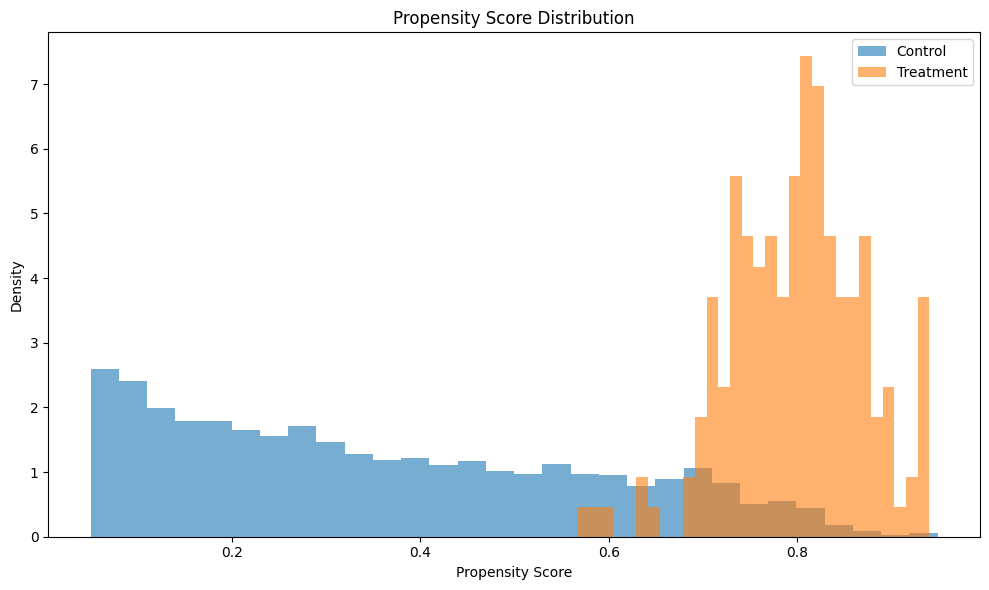

2026-05-18 11:16:56,373 | INFO | PLOT UPLIFT DISTRIBUTION


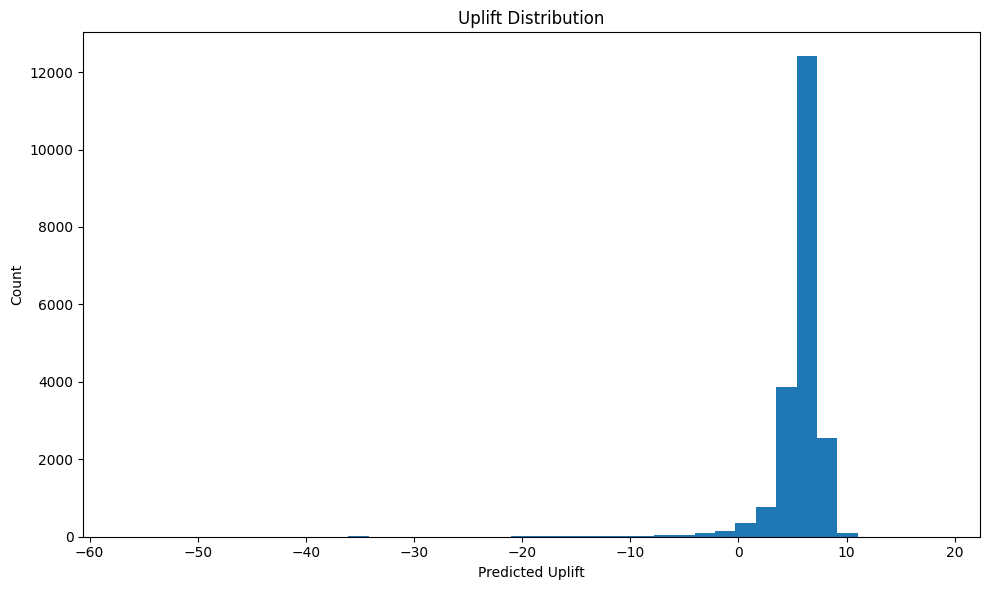

In [18]:
# =========================================================
# PLOTS
# =========================================================

logger.info("PLOT PROPENSITY DISTRIBUTION")

plot_propensity_distribution(
    result["df_predictions"]
)

plt.show()

logger.info("PLOT UPLIFT DISTRIBUTION")

plot_uplift_distribution(
    result["df_predictions"]
)

plt.show()

In [19]:
# =========================================================
# TOP UPLIFT USERS
# =========================================================

print("\n" + "=" * 60)
print("TOP UPLIFT USERS")
print("=" * 60)

top_users = (
    result["df_predictions"]
    .sort_values(
        "uplift",
        ascending=False,
    )
    .head(20)
)

display(top_users)


TOP UPLIFT USERS


,customer_rk,revenue_pre,revenue_post,y,T,customer_id,orders_cnt,revenue_sum,avg_check,discount_share,...,age_Возраст_55_59,age_Возраст_60_69,age_Возраст_70_79,age_Возраст_больше_80,gender_Женский пол,gender_Мужской пол,propensity_score,uplift,tau_0_pred,tau_1_pred
17040,9ed83099f8a78119163deb47d9b69351,2723.0,0.0,0.0,0,736572,2,2723.0,1361.5,0.0,...,0,0,0,0,1,0,0.673932,18.566438,24.929672,5.414645
19594,448100ed4b9d2fcb1cba7ae93183bb9c,2736.0,0.0,0.0,0,924438775,2,2736.0,1368.0,0.0,...,0,0,0,0,1,0,0.688815,18.383042,24.241767,5.414645
2383,fb124849261045e702556c92de7c3e25,2983.0,0.0,0.0,0,693602663,2,2983.0,1491.5,0.0,...,0,0,0,0,1,0,0.485224,16.664703,28.599918,5.414645
7073,3354df37b9404e3b2c417a29329b9a69,2933.0,0.0,0.0,0,7924914,2,2933.0,1466.5,0.0,...,0,0,0,0,1,0,0.404271,14.769115,28.553777,5.414645
36666,02f3ea735e7a6b92111332375afc2de9,1007.0,0.0,0.0,0,67133542,1,1007.0,1007.0,0.0,...,0,0,0,0,1,0,0.543920,14.074448,21.335733,5.414645
10039,b39de4796f0a3efeb12c3dda90a8a1be,2915.0,0.0,0.0,0,907049637,2,2915.0,1457.5,0.0,...,0,0,0,0,0,1,0.399326,13.412593,25.443290,5.414645
507,1579aadb1d794849ecf7ad9939a66fde,652.0,0.0,0.0,0,4766052,1,652.0,652.0,0.0,...,0,0,0,0,1,0,0.728332,12.038454,14.509138,5.414645
3328,1d33780fd33ad8b6326abc912dc80867,817.0,0.0,0.0,1,2775061,1,817.0,817.0,0.0,...,0,0,0,0,0,1,0.928608,11.874311,12.370935,5.414645
29072,b72639f96998b8788e1663e5a5c3b8b5,2665.0,0.0,0.0,1,679379863,1,2665.0,2665.0,0.0,...,0,0,0,0,0,1,0.832753,11.261987,12.436347,5.414645
24339,c366a3ecf81f47bdd42600d48237aa35,2458.0,0.0,0.0,1,5324775,1,2458.0,2458.0,0.0,...,0,0,0,0,1,0,0.862068,11.213783,12.141651,5.414645


In [20]:
# =========================================================
# SAVE ARTIFACT
# =========================================================

logger.info("=" * 60)
logger.info("SAVE PARQUET")
logger.info("=" * 60)

artifacts_dir = (
    PROJECT_ROOT / "artifacts"
)

artifacts_dir.mkdir(
    exist_ok=True
)

output_path = (
    artifacts_dir / "vesna_uplift.parquet"
)

table = pa.Table.from_pandas(
    result["df_predictions"]
)

pq.write_table(
    table,
    output_path,
)

logger.info(
    f"Saved parquet to: {output_path}"
)

print("\nPARQUET SAVED:")
print(output_path)

2026-05-18 11:17:05,794 | INFO | ============================================================
2026-05-18 11:17:05,796 | INFO | SAVE PARQUET
2026-05-18 11:17:05,797 | INFO | ============================================================
2026-05-18 11:17:05,918 | INFO | Saved parquet to: /Users/hq-fvfkjjjz1wfv/Documents/tasks/Инкремент/offline_uplift/artifacts/vesna_uplift.parquet



PARQUET SAVED:
/Users/hq-fvfkjjjz1wfv/Documents/tasks/Инкремент/offline_uplift/artifacts/vesna_uplift.parquet


In [21]:
# =========================================================
# FINAL SUMMARY
# =========================================================

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print(
    f"""
Promo: {PROMO_CODE}

Incremental Revenue:
{round(result["incremental_revenue"], 2)} ₽

ATE DML:
{result["ate_dml"]}

Dataset Shape:
{result["dataset_shape"]}

Feature Count:
{result["feature_count"]}

Trimmed Rows:
{result["trimmed_rows"]}
"""
)


FINAL SUMMARY


KeyError: 'trimmed_rows'